# 🚀 Simple MobileNetV3 Plant Disease Detection
**Load** → **Train** → **Predict** với auto-continue training

In [9]:
# IMPORTS
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import mobilenet_v3_large
from PIL import Image
import os
import numpy as np
from tqdm import tqdm
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [10]:
# MODEL DEFINITION
class SimpleMobileNetV3(nn.Module):
    def __init__(self, num_classes):
        super(SimpleMobileNetV3, self).__init__()
        self.mobilenet = mobilenet_v3_large(weights='IMAGENET1K_V1')
        # Replace the last layer of the classifier
        in_features = self.mobilenet.classifier[3].in_features
        self.mobilenet.classifier[3] = nn.Linear(in_features, num_classes)
    
    def forward(self, x):
        return self.mobilenet(x)

# SIMPLE DATASET
class SimpleDataset(Dataset):
    def __init__(self, root_dir, transform=None, is_training=True):
        # Enhanced data augmentation for better accuracy
        if is_training:
            self.transform = transform or transforms.Compose([
                transforms.Resize((256, 256)),  # Larger resize for better crop diversity
                transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Random crop
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.3),  # Useful for plant diseases
                transforms.RandomRotation(degrees=30),  # Disease orientation varies
                transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
                transforms.RandomAffine(degrees=0, shear=10),  # Slight shear
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
                # Add random erasing (cutout) for robustness
                transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3))
            ])
        else:
            # Validation/test transform (no augmentation)
            self.transform = transform or transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
            ])
        
        self.samples = []
        self.classes = []
        
        if os.path.exists(root_dir):
            for class_name in os.listdir(root_dir):
                class_path = os.path.join(root_dir, class_name)
                if os.path.isdir(class_path):
                    self.classes.append(class_name)
                    class_idx = len(self.classes) - 1
                    
                    # Load ALL files - no limits
                    files = [f for f in os.listdir(class_path) 
                            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                    
                    for file in files:
                        self.samples.append((os.path.join(class_path, file), class_idx))
        
        print(f"Loaded {len(self.samples)} samples, {len(self.classes)} classes")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            image = Image.open(path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except:
            # Return black image on error
            return torch.zeros(3, 224, 224), label

print("Model and Dataset defined!")

Model and Dataset defined!


In [11]:
# CHECKPOINT MANAGEMENT
CHECKPOINT_DIR = "./modelsCP"
FOUNDATION_PATH = f"{CHECKPOINT_DIR}/mobilenet_foundation/mobilenet_foundation_best.pth"
FINETUNE_PATH = f"{CHECKPOINT_DIR}/mobilenet_finetune/mobilenet_finetune_best.pth"

def save_checkpoint(model, acc, class_names, path, info=""):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({
        'model_state_dict': model.state_dict(),
        'accuracy': acc,
        'class_names': class_names,
        'num_classes': len(class_names),
        'timestamp': time.time()
    }, path)
    print(f"✅ Saved {info}: {acc:.2f}% - {path}")

def load_checkpoint(path, num_classes):
    if os.path.exists(path):
        print(f"📂 Loading checkpoint: {path}")
        try:
            checkpoint = torch.load(path, map_location=device, weights_only=True)
            
            model = SimpleMobileNetV3(num_classes=checkpoint['num_classes']).to(device)
            model.load_state_dict(checkpoint['model_state_dict'])
            
            print(f"✅ Loaded - Acc: {checkpoint['accuracy']:.2f}%, Classes: {checkpoint['num_classes']}")
            return model, checkpoint['class_names'], checkpoint['accuracy']
        except Exception as e:
            print(f"❌ Checkpoint incompatible: {e}")
            print("🗑️ Removing old checkpoint...")
            os.remove(path)
            return None, [], 0.0
    return None, [], 0.0

print("Checkpoint functions ready!")

Checkpoint functions ready!


In [12]:
# LOAD PLANT DISEASE DATASET
plant_dataset = SimpleDataset("./dataset/PlantVillage/color", is_training=True)  # For training data
plant_classes = plant_dataset.classes

# Split dataset properly
train_size = int(0.8 * len(plant_dataset))
val_size = len(plant_dataset) - train_size

# Create proper random split
train_dataset, val_dataset_temp = torch.utils.data.random_split(plant_dataset, [train_size, val_size])

# Create validation dataset without augmentation
val_dataset = SimpleDataset("./dataset/PlantVillage/color", is_training=False)
val_indices = list(range(train_size, len(val_dataset)))
val_dataset = torch.utils.data.Subset(val_dataset, val_indices)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"📊 Train: {train_size}, Val: {val_size}, Classes: {len(plant_classes)}")
print("✅ Enhanced data augmentation applied for training!")

Loaded 54305 samples, 38 classes
Loaded 54305 samples, 38 classes
📊 Train: 43444, Val: 10861, Classes: 38
✅ Enhanced data augmentation applied for training!
Loaded 54305 samples, 38 classes
📊 Train: 43444, Val: 10861, Classes: 38
✅ Enhanced data augmentation applied for training!


In [13]:
# 🎯 LOAD - All-in-One Setup với Foundation/Finetune Logic
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from torchvision import transforms
from torchvision.models import mobilenet_v3_large
from PIL import Image
import os
import numpy as np
from tqdm import tqdm
import time
import torch.nn.functional as F

print("🚀 STARTING LOAD PROCESS...")
print("=" * 50)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")

# Model definition
class SimpleMobileNetV3(nn.Module):
    def __init__(self, num_classes):
        super(SimpleMobileNetV3, self).__init__()
        self.mobilenet = mobilenet_v3_large(weights='IMAGENET1K_V1')
        in_features = self.mobilenet.classifier[3].in_features
        self.mobilenet.classifier[3] = nn.Linear(in_features, num_classes)
    
    def forward(self, x):
        return self.mobilenet(x)

# Enhanced Dataset class với progress tracking
class SimpleDataset(Dataset):
    def __init__(self, root_dir, transform=None, is_training=True, name="Dataset"):
        print(f"📁 Loading {name} from: {root_dir}")
        
        if is_training:
            self.transform = transform or transforms.Compose([
                transforms.Resize((256, 256)),
                transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.3),
                transforms.RandomRotation(degrees=30),
                transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
                transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3))
            ])
        else:
            self.transform = transform or transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
            ])
        
        self.samples = []
        self.classes = []
        
        if os.path.exists(root_dir):
            # Đếm classes trước để có progress bar
            class_dirs = [d for d in os.listdir(root_dir) 
                         if os.path.isdir(os.path.join(root_dir, d))]
            
            print(f"   📂 Found {len(class_dirs)} classes")
            
            # Progress bar cho việc load classes
            class_pbar = tqdm(
                class_dirs, 
                desc=f"   🔄 Loading {name} classes",
                ncols=80,
                bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}, {rate_fmt}] {postfix}'
            )
            
            total_files = 0
            for class_name in class_pbar:
                class_path = os.path.join(root_dir, class_name)
                self.classes.append(class_name)
                class_idx = len(self.classes) - 1
                
                # Đếm files trong class
                files = [f for f in os.listdir(class_path) 
                        if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                
                # Add files với progress update
                for file in files:
                    self.samples.append((os.path.join(class_path, file), class_idx))
                    total_files += 1
                
                # Update progress với info
                class_pbar.set_postfix({
                    'Class': class_name[:15],
                    'Files': len(files),
                    'Total': total_files
                })
            
            print(f"   ✅ {name}: {len(self.samples)} samples, {len(self.classes)} classes")
        else:
            print(f"   ❌ {name}: Path not found - {root_dir}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        try:
            image = Image.open(path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except:
            return torch.zeros(3, 224, 224), label

# Checkpoint management - FIXED PATHS
CHECKPOINT_DIR = "./modelsCP"
FOUNDATION_PATH = f"{CHECKPOINT_DIR}/mobilenet_foundation/mobilenet_foundation_best.pth"
FINETUNE_PATH = f"{CHECKPOINT_DIR}/mobilenet_finetune/mobilenet_finetune_best.pth"

def save_checkpoint(model, acc, class_names, path, info=""):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({
        'model_state_dict': model.state_dict(),
        'accuracy': acc,
        'class_names': class_names,
        'num_classes': len(class_names),
        'timestamp': time.time()
    }, path)
    print(f"✅ Saved {info}: {acc:.2f}% - {path}")

def load_checkpoint(path, expected_classes=None):
    if os.path.exists(path):
        print(f"📂 Loading checkpoint: {path}")
        try:
            print("   🔄 Reading checkpoint file...")
            checkpoint = torch.load(path, map_location=device, weights_only=True)
            
            print("   🏗️  Building model architecture...")
            model = SimpleMobileNetV3(num_classes=checkpoint['num_classes']).to(device)
            
            print("   ⚡ Loading model weights...")
            model.load_state_dict(checkpoint['model_state_dict'])
            
            print(f"   ✅ Checkpoint loaded successfully!")
            print(f"   📊 Accuracy: {checkpoint['accuracy']:.2f}%")
            print(f"   🎯 Classes: {checkpoint['num_classes']}")
            return model, checkpoint['class_names'], checkpoint['accuracy']
        except Exception as e:
            print(f"   ❌ Error loading checkpoint: {e}")
            return None, [], 0.0
    else:
        print(f"   ℹ️  No checkpoint found at: {path}")
    return None, [], 0.0

# Load datasets với detailed progress
print("\n📦 LOADING DATASETS...")
print("=" * 50)

# Progress simulation for dataset loading
load_steps = [
    ("PlantVillage Dataset", "./dataset/PlantVillage/color"),
    ("Durian Dataset", "./dataset/Durian_Leaf_Diseases/train")
]

datasets = {}
for step_name, path in load_steps:
    print(f"\n🔄 {step_name}:")
    if "PlantVillage" in step_name:
        datasets['plant'] = SimpleDataset(path, is_training=True, name="PlantVillage")
    else:
        datasets['durian'] = SimpleDataset(path, is_training=True, name="Durian")

plant_dataset = datasets['plant']
durian_dataset = datasets['durian']

# Combine class names với progress
print(f"\n🔗 COMBINING DATASETS...")
print("   🔄 Merging class names...")

all_class_names = plant_dataset.classes + durian_dataset.classes
total_classes = len(all_class_names)

print(f"   ✅ Combined classes:")
print(f"      🌱 PlantVillage: {len(plant_dataset.classes)} classes")
print(f"      🥥 Durian: {len(durian_dataset.classes)} classes") 
print(f"      📊 Total: {total_classes} classes")

# SMART MODEL LOADING LOGIC
print(f"\n🤖 SMART MODEL LOADING...")
print("=" * 50)

model = None
class_names = []
current_accuracy = 0.0

# Step 1: Try to load FINETUNE model first (most complete)
print("🔍 Step 1: Checking for FINETUNE model...")
model, class_names, current_accuracy = load_checkpoint(FINETUNE_PATH, total_classes)

if model is not None:
    print("🎉 FINETUNE model found! Ready to continue training.")
    MODEL_PATH = FINETUNE_PATH
    training_stage = "FINETUNE_CONTINUE"
else:
    # Step 2: Try to load FOUNDATION model
    print("\n🔍 Step 2: Checking for FOUNDATION model...")
    model, class_names, current_accuracy = load_checkpoint(FOUNDATION_PATH, len(plant_dataset.classes))
    
    if model is not None:
        print("🏗️  FOUNDATION model found! Will continue to finetune stage.")
        MODEL_PATH = FINETUNE_PATH  # Will save as finetune
        training_stage = "FINETUNE_FROM_FOUNDATION"
        
        # Need to rebuild model for full classes if foundation only has plant classes
        if len(class_names) != total_classes:
            print("   🔧 Rebuilding model for combined classes...")
            old_model = model
            model = SimpleMobileNetV3(total_classes).to(device)
            
            # Copy foundation weights to new model
            with torch.no_grad():
                # Copy all weights except the final classification layer
                for name, param in old_model.named_parameters():
                    if 'classifier.3' not in name:
                        model.state_dict()[name].copy_(param)
                
                # Copy PlantVillage classes weights to new head
                old_head_weight = old_model.mobilenet.classifier[3].weight.data
                old_head_bias = old_model.mobilenet.classifier[3].bias.data
                
                # Initialize new head
                nn.init.normal_(model.mobilenet.classifier[3].weight, std=0.01)
                nn.init.zeros_(model.mobilenet.classifier[3].bias)
                
                # Copy PlantVillage weights
                model.mobilenet.classifier[3].weight.data[:len(plant_dataset.classes)] = old_head_weight
                model.mobilenet.classifier[3].bias.data[:len(plant_dataset.classes)] = old_head_bias
            
            class_names = all_class_names
            print("   ✅ Model rebuilt for combined training!")
    else:
        # Step 3: Create new model
        print("\n🚀 Step 3: Creating NEW model...")
        
        # Progress simulation for model creation
        creation_steps = [
            "🏗️  Initializing MobileNetV3-Large architecture...",
            "📦 Loading ImageNet pretrained weights...", 
            "🎯 Setting up classification head...",
            "⚡ Moving model to device...",
            "🔧 Setting up model parameters..."
        ]
        
        for step in tqdm(creation_steps, desc="   Creating Model", ncols=80):
            time.sleep(0.3)  # Simulate processing time
        
        model = SimpleMobileNetV3(total_classes).to(device)
        current_accuracy = 0.0
        class_names = all_class_names
        MODEL_PATH = FOUNDATION_PATH  # Will start with foundation training
        training_stage = "FOUNDATION_NEW"
        
        print(f"   ✅ New model created successfully!")

# Model info
print(f"\n📋 MODEL SUMMARY:")
print("=" * 50)
print(f"🎯 Current accuracy: {current_accuracy:.2f}%")
print(f"🔢 Total classes: {len(class_names)}")
print(f"💾 Model path: {MODEL_PATH}")
print(f"🚀 Training stage: {training_stage}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"🧠 Parameters:")
print(f"   📊 Total: {total_params:,}")
print(f"   🎯 Trainable: {trainable_params:,}")

print(f"\n🎉 LOAD COMPLETE!")
print("=" * 50)
print("🔄 Ready for training or prediction!")

🚀 STARTING LOAD PROCESS...
🖥️  Device: cuda

📦 LOADING DATASETS...

🔄 PlantVillage Dataset:
📁 Loading PlantVillage from: ./dataset/PlantVillage/color
   📂 Found 38 classes


   🔄 Loading PlantVillage classes: 100%|█| 38/38 [00:00, 228.93it/s] , Class=To


   ✅ PlantVillage: 54305 samples, 38 classes

🔄 Durian Dataset:
📁 Loading Durian from: ./dataset/Durian_Leaf_Diseases/train
   📂 Found 6 classes


   🔄 Loading Durian classes: 100%|█| 6/6 [00:00, 666.71it/s] , Class=Leaf_Rhizo


   ✅ Durian: 1814 samples, 6 classes

🔗 COMBINING DATASETS...
   🔄 Merging class names...
   ✅ Combined classes:
      🌱 PlantVillage: 38 classes
      🥥 Durian: 6 classes
      📊 Total: 44 classes

🤖 SMART MODEL LOADING...
🔍 Step 1: Checking for FINETUNE model...
   ℹ️  No checkpoint found at: ./modelsCP/mobilenet_finetune/mobilenet_finetune_best.pth

🔍 Step 2: Checking for FOUNDATION model...
   ℹ️  No checkpoint found at: ./modelsCP/mobilenet_foundation/mobilenet_foundation_best.pth

🚀 Step 3: Creating NEW model...


   Creating Model: 100%|██████████████████████████| 5/5 [00:01<00:00,  3.21it/s]

   ✅ New model created successfully!

📋 MODEL SUMMARY:
🎯 Current accuracy: 0.00%
🔢 Total classes: 44
💾 Model path: ./modelsCP/mobilenet_foundation/mobilenet_foundation_best.pth
🚀 Training stage: FOUNDATION_NEW
🧠 Parameters:
   📊 Total: 4,258,396
   🎯 Trainable: 4,258,396

🎉 LOAD COMPLETE!
🔄 Ready for training or prediction!


In [14]:
# 🚀 TRAIN - Foundation → Finetune Training

# ⚙️ TRAINING CONFIGURATION - EDIT HERE
FOUNDATION_EPOCHS = 2  # ✏️ Foundation training epochs (PlantVillage only)
FINETUNE_EPOCHS = 1   # ✏️ Finetune training epochs (PlantVillage + Durian)

import sys
import time

def print_immediate(text):
    """Print immediately without buffering"""
    print(text)
    sys.stdout.flush()

print_immediate(f"🔧 TRAINING CONFIG:")
print_immediate(f"   🏗️  Foundation: {FOUNDATION_EPOCHS} epochs")
print_immediate(f"   🎯 Finetune: {FINETUNE_EPOCHS} epochs")
print_immediate("=" * 60)

def train_foundation(epochs):
    """
    Train Foundation model - PlantVillage only
    """
    
    global model, current_accuracy, training_stage
    
    print_immediate(f"\n🏗️  FOUNDATION TRAINING")
    print_immediate(f"📊 Dataset: PlantVillage only ({len(plant_dataset.classes)} classes)")
    print_immediate(f"🔥 Training for {epochs} epochs")
    print_immediate("=" * 60)
    
    # Setup foundation training data (PlantVillage only)
    print_immediate("🔧 Setting up data loader...")
    foundation_loader = DataLoader(plant_dataset, batch_size=32, shuffle=True, num_workers=0)
    
    print_immediate(f"📊 Training data: {len(plant_dataset)} PlantVillage samples")
    print_immediate(f"🔄 Batches per epoch: {len(foundation_loader)}")
    
    # Conservative training: freeze backbone, only train classifier
    print_immediate("🔧 Configuring model parameters...")
    model.train()
    frozen_params = 0
    trainable_params = 0
    for name, param in model.named_parameters():
        if 'classifier.3' not in name:
            param.requires_grad = False
            frozen_params += param.numel()
        else:
            param.requires_grad = True
            trainable_params += param.numel()
    
    print_immediate(f"🔒 Frozen params: {frozen_params:,} | 🎯 Trainable params: {trainable_params:,}")
    
    print_immediate("🔧 Setting up optimizer...")
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    best_acc = current_accuracy
    total_start_time = time.time()
    epoch_results = []
    
    print_immediate("🚀 Starting training loop...")
    
    for epoch in range(epochs):
        epoch_start = time.time()
        print_immediate(f"\n{'='*15} FOUNDATION EPOCH {epoch+1}/{epochs} {'='*15}")
        
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0
        
        # More compact progress tracking - only tqdm bar, less verbose output
        train_pbar = tqdm(
            foundation_loader, 
            desc=f"🏗️  Foundation {epoch+1}/{epochs}",
            ncols=120,
            bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}',
            leave=True
        )
        
        batch_count = 0
        for batch_idx, (data, targets) in enumerate(train_pbar):
            batch_count += 1
            data, targets = data.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += targets.size(0)
            train_correct += (predicted == targets).sum().item()
            
            current_train_acc = 100. * train_correct / train_total
            avg_loss = running_loss / (batch_idx + 1)
            
            # Update tqdm with compact info
            train_pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{current_train_acc:.2f}%',
                'LR': f'{scheduler.get_last_lr()[0]:.2e}',
                'Batch': f'{batch_count}/{len(foundation_loader)}'
            })
            
            # COMPACT: Only print every 50 batches to reduce output
            if batch_count % 50 == 0:
                print_immediate(f"      ⚡ {batch_count}/{len(foundation_loader)} batches | Loss: {loss.item():.4f} | Acc: {current_train_acc:.2f}%")
        
        train_acc = 100. * train_correct / train_total
        scheduler.step()
        epoch_time = time.time() - epoch_start
        avg_loss = running_loss / len(foundation_loader)
        improvement = train_acc - best_acc
        
        print_immediate(f"\n📊 FOUNDATION EPOCH {epoch+1} RESULTS:")
        print_immediate(f"   ⏱️  Time: {epoch_time:.1f}s | 📉 Loss: {avg_loss:.4f} | 🎯 Accuracy: {train_acc:.2f}% | 📈 Improvement: {improvement:+.2f}%")
        
        epoch_results.append({
            'epoch': epoch + 1,
            'loss': avg_loss,
            'accuracy': train_acc,
            'improvement': improvement,
            'time': epoch_time
        })
        
        if train_acc > best_acc:
            best_acc = train_acc
            current_accuracy = best_acc
            print_immediate(f"   💾 Saving best model...")
            save_checkpoint(model, current_accuracy, plant_dataset.classes, FOUNDATION_PATH, f"Foundation Epoch {epoch+1}")
            print_immediate(f"   🎉 NEW BEST! Foundation saved.")
        else:
            print_immediate(f"   📊 No improvement, best: {best_acc:.2f}%")
    
    total_time = time.time() - total_start_time
    print_immediate(f"\n🏗️  FOUNDATION COMPLETE!")
    print_immediate(f"⏱️  Total time: {total_time:.1f}s | 🎯 Final accuracy: {best_acc:.2f}%")
    
    return best_acc

def train_finetune(epochs):
    """
    Train Finetune model - PlantVillage + Durian
    🔧 KỸ THUẬT CHỐNG QUÊN DATA: 
    1. WEIGHT INHERITANCE: Copy foundation weights làm khởi điểm
    2. BALANCED SAMPLING: Giữ cân bằng PlantVillage/Durian data  
    3. CONSERVATIVE LEARNING: Freeze backbone, chỉ train classifier
    4. KNOWLEDGE PRESERVATION: PlantVillage weights được giữ nguyên trong finetune head
    """
    
    global model, current_accuracy, training_stage
    
    print_immediate(f"\n🎯 FINETUNE TRAINING")
    print_immediate(f"📊 Dataset: PlantVillage + Durian ({len(all_class_names)} classes)")
    print_immediate(f"🔥 Training for {epochs} epochs")
    print_immediate("=" * 60)
    
    # Rebuild model for combined classes if needed
    print_immediate("🔧 Rebuilding model for combined classes...")
    old_model = model
    model = SimpleMobileNetV3(len(all_class_names)).to(device)
    
    # 🔑 KỸ THUẬT 1: WEIGHT INHERITANCE - Copy foundation weights
    print_immediate("   📋 Copying foundation weights (Anti-forgetting)...")
    with torch.no_grad():
        for name, param in old_model.named_parameters():
            if 'classifier.3' not in name:
                model.state_dict()[name].copy_(param)
        
        # 🔑 KỸ THUẬT 2: KNOWLEDGE PRESERVATION - Keep PlantVillage knowledge
        old_head_weight = old_model.mobilenet.classifier[3].weight.data
        old_head_bias = old_model.mobilenet.classifier[3].bias.data
        
        nn.init.normal_(model.mobilenet.classifier[3].weight, std=0.01)
        nn.init.zeros_(model.mobilenet.classifier[3].bias)
        
        # Preserve PlantVillage weights in new head
        model.mobilenet.classifier[3].weight.data[:len(plant_dataset.classes)] = old_head_weight
        model.mobilenet.classifier[3].bias.data[:len(plant_dataset.classes)] = old_head_bias
    
    print_immediate("   ✅ Model rebuilt with foundation knowledge preserved!")
    
    # 🔑 KỸ THUẬT 3: BALANCED SAMPLING - Prevent data imbalance
    print_immediate("🔧 Preparing balanced training data...")
    plant_subset_size = len(durian_dataset)
    plant_indices = torch.randperm(len(plant_dataset))[:plant_subset_size]
    plant_subset = torch.utils.data.Subset(plant_dataset, plant_indices)
    
    print_immediate(f"   📊 Balanced sampling: {len(plant_subset)} PlantVillage = {len(durian_dataset)} Durian")
    
    # Adjust durian labels
    class DurianAdjusted(Dataset):
        def __init__(self, dataset):
            self.dataset = dataset
        def __len__(self):
            return len(self.dataset)
        def __getitem__(self, idx):
            data, label = self.dataset[idx]
            return data, label + len(plant_dataset.classes)
    
    durian_adjusted = DurianAdjusted(durian_dataset)
    combined_dataset = ConcatDataset([plant_subset, durian_adjusted])
    
    print_immediate("🔧 Creating data loader...")
    finetune_loader = DataLoader(combined_dataset, batch_size=32, shuffle=True, num_workers=0)
    
    print_immediate(f"📊 Training data: {len(plant_subset)} PlantVillage + {len(durian_dataset)} Durian = {len(combined_dataset)} total")
    print_immediate(f"🔄 Batches per epoch: {len(finetune_loader)}")
    
    # 🔑 KỸ THUẬT 4: CONSERVATIVE TRAINING - Freeze backbone
    print_immediate("🔧 Configuring model parameters...")
    model.train()
    frozen_params = 0
    trainable_params = 0
    for name, param in model.named_parameters():
        if 'classifier.3' not in name:
            param.requires_grad = False  # Freeze để tránh quên
            frozen_params += param.numel()
        else:
            param.requires_grad = True
            trainable_params += param.numel()
    
    print_immediate(f"🔒 CONSERVATIVE: Frozen {frozen_params:,} | Trainable {trainable_params:,}")
    
    print_immediate("🔧 Setting up optimizer...")
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    # Reset best_acc for finetuning stage to ensure checkpoint is saved
    best_acc = 0.0 
    total_start_time = time.time()
    epoch_results = []
    
    print_immediate("🚀 Starting finetune training loop...")
    
    for epoch in range(epochs):
        epoch_start = time.time()
        print_immediate(f"\n{'='*15} FINETUNE EPOCH {epoch+1}/{epochs} {'='*15}")
        
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0
        
        # More compact progress tracking - only tqdm bar, less verbose output
        train_pbar = tqdm(
            finetune_loader, 
            desc=f"🎯 Finetune {epoch+1}/{epochs}",
            ncols=120,
            bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}] {postfix}',
            leave=True
        )
        
        batch_count = 0
        for batch_idx, (data, targets) in enumerate(train_pbar):
            batch_count += 1
            data, targets = data.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += targets.size(0)
            train_correct += (predicted == targets).sum().item()
            
            current_train_acc = 100. * train_correct / train_total
            avg_loss = running_loss / (batch_idx + 1)
            
            # Update tqdm with compact info
            train_pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{current_train_acc:.2f}%',
                'LR': f'{scheduler.get_last_lr()[0]:.2e}',
                'Batch': f'{batch_count}/{len(finetune_loader)}'
            })
            
            # COMPACT: Only print every 50 batches to reduce output
            if batch_count % 50 == 0:
                print_immediate(f"      ⚡ {batch_count}/{len(finetune_loader)} batches | Loss: {loss.item():.4f} | Acc: {current_train_acc:.2f}%")
        
        train_acc = 100. * train_correct / train_total
        scheduler.step()
        epoch_time = time.time() - epoch_start
        avg_loss = running_loss / len(finetune_loader)
        improvement = train_acc - best_acc
        
        print_immediate(f"\n📊 FINETUNE EPOCH {epoch+1} RESULTS:")
        print_immediate(f"   ⏱️  Time: {epoch_time:.1f}s | 📉 Loss: {avg_loss:.4f} | 🎯 Accuracy: {train_acc:.2f}% | 📈 Improvement: {improvement:+.2f}%")
        
        epoch_results.append({
            'epoch': epoch + 1,
            'loss': avg_loss,
            'accuracy': train_acc,
            'improvement': improvement,
            'time': epoch_time
        })
        
        if train_acc > best_acc:
            best_acc = train_acc
            current_accuracy = best_acc
            print_immediate(f"   💾 Saving best model...")
            save_checkpoint(model, current_accuracy, all_class_names, FINETUNE_PATH, f"Finetune Epoch {epoch+1}")
            print_immediate(f"   🎉 NEW BEST! Finetune saved.")
        else:
            print_immediate(f"   📊 No improvement, best: {best_acc:.2f}%")
    
    total_time = time.time() - total_start_time
    print_immediate(f"\n🎯 FINETUNE COMPLETE!")
    print_immediate(f"⏱️  Total time: {total_time:.1f}s | 🎯 Final accuracy: {best_acc:.2f}%")
    
    return best_acc

# 🚀 TRAINING PIPELINE - ALWAYS Foundation → Finetune
print_immediate(f"🚀 STARTING TRAINING PIPELINE...")
print_immediate("📋 STRATEGY: Always train Foundation first, then Finetune")
print_immediate("=" * 70)

# 🔍 Step 1: SETUP FOUNDATION MODEL
print_immediate("🔍 STEP 1: SETTING UP FOUNDATION MODEL")
print_immediate("=" * 50)

# Check if Foundation checkpoint exists
foundation_model = None
foundation_class_names = []
foundation_accuracy = 0.0

print_immediate("🔍 Checking for existing foundation checkpoint...")

if os.path.exists(FOUNDATION_PATH):
    print_immediate("📂 Foundation checkpoint found! Loading...")
    try:
        print_immediate("   🔄 Reading checkpoint file...")
        checkpoint = torch.load(FOUNDATION_PATH, map_location=device, weights_only=True)
        
        print_immediate("   🏗️  Building model...")
        foundation_model = SimpleMobileNetV3(num_classes=checkpoint['num_classes']).to(device)
        
        print_immediate("   ⚡ Loading weights...")
        foundation_model.load_state_dict(checkpoint['model_state_dict'])
        foundation_class_names = checkpoint['class_names']
        foundation_accuracy = checkpoint['accuracy']
        
        print_immediate(f"   ✅ Foundation loaded: {foundation_accuracy:.2f}% accuracy")
        print_immediate(f"   📊 Classes: {len(foundation_class_names)}")
        
        # Use foundation model as starting point
        model = foundation_model
        current_accuracy = foundation_accuracy
        class_names = foundation_class_names
        
    except Exception as e:
        print_immediate(f"   ❌ Error loading foundation: {e}")
        print_immediate("   🔄 Will create new foundation model")
        foundation_model = None
else:
    print_immediate("   ℹ️  No foundation checkpoint found")
    print_immediate("   🔄 Will create new foundation model")

if foundation_model is None:
    print_immediate("🏗️  Creating new foundation model...")
    print_immediate("   🔧 Initializing MobileNetV3 architecture...")
    model = SimpleMobileNetV3(len(plant_dataset.classes)).to(device)
    current_accuracy = 0.0
    class_names = plant_dataset.classes
    print_immediate(f"   ✅ New foundation model created for {len(plant_dataset.classes)} PlantVillage classes")

print_immediate(f"📊 Foundation setup complete: {current_accuracy:.2f}% accuracy")

# 🏗️  Step 2: TRAIN FOUNDATION
print_immediate(f"\n🏗️  STEP 2: FOUNDATION TRAINING")
print_immediate("=" * 50)
print_immediate(f"🎯 Training Foundation for {FOUNDATION_EPOCHS} epochs...")

foundation_result = train_foundation(FOUNDATION_EPOCHS)

print_immediate(f"✅ Foundation training complete: {foundation_result:.2f}% accuracy")
print_immediate(f"💾 Foundation saved to: {FOUNDATION_PATH}")

# 🎯 Step 3: TRAIN FINETUNE
print_immediate(f"\n🎯 STEP 3: FINETUNE TRAINING")
print_immediate("=" * 50)
print_immediate(f"🔄 Loading foundation model for finetune...")

# Load the best foundation model for finetune
if os.path.exists(FOUNDATION_PATH):
    print_immediate("   📂 Loading best foundation checkpoint...")
    checkpoint = torch.load(FOUNDATION_PATH, map_location=device, weights_only=True)
    model = SimpleMobileNetV3(num_classes=checkpoint['num_classes']).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    current_accuracy = checkpoint['accuracy']
    print_immediate(f"   📂 Foundation loaded: {current_accuracy:.2f}% accuracy")
else:
    print_immediate("   ⚠️  Foundation not found, using current model")

print_immediate(f"🎯 Training Finetune for {FINETUNE_EPOCHS} epochs...")

finetune_result = train_finetune(FINETUNE_EPOCHS)

print_immediate(f"✅ Finetune training complete: {finetune_result:.2f}% accuracy")
print_immediate(f"💾 Finetune saved to: {FINETUNE_PATH}")

# 🎉 FINAL SUMMARY
print_immediate(f"\n" + "="*70)
print_immediate(f"🎉 TRAINING PIPELINE COMPLETED!")
print_immediate(f"🏗️  Foundation result: {foundation_result:.2f}% accuracy")
print_immediate(f"🎯 Finetune result: {finetune_result:.2f}% accuracy")
print_immediate(f"📈 Total improvement: {finetune_result - foundation_result:+.2f}%")
print_immediate(f"💾 Models saved:")
print_immediate(f"   🏗️  Foundation: {FOUNDATION_PATH}")
print_immediate(f"   🎯 Finetune: {FINETUNE_PATH}")
print_immediate(f"🔧 Anti-forgetting techniques applied:")
print_immediate(f"   1. 🧠 Weight Inheritance: Foundation → Finetune")
print_immediate(f"   2. ⚖️  Balanced Sampling: Equal PlantVillage/Durian data")
print_immediate(f"   3. 🔒 Conservative Training: Frozen backbone")
print_immediate(f"   4. 📋 Knowledge Preservation: PlantVillage weights preserved")
print_immediate("✅ Ready for prediction!")

🔧 TRAINING CONFIG:
   🏗️  Foundation: 2 epochs
   🎯 Finetune: 1 epochs
   🏗️  Foundation: 2 epochs
   🎯 Finetune: 1 epochs


🚀 STARTING TRAINING PIPELINE...
📋 STRATEGY: Always train Foundation first, then Finetune
🔍 STEP 1: SETTING UP FOUNDATION MODEL
🔍 Checking for existing foundation checkpoint...
   ℹ️  No foundation checkpoint found
   🔄 Will create new foundation model
🏗️  Creating new foundation model...
   🔧 Initializing MobileNetV3 architecture...
📋 STRATEGY: Always train Foundation first, then Finetune
🔍 STEP 1: SETTING UP FOUNDATION MODEL
🔍 Checking for existing foundation checkpoint...
   ℹ️  No foundation checkpoint found
   🔄 Will create new foundation model
🏗️  Creating new foundation model...
   🔧 Initializing MobileNetV3 architecture...
   ✅ New foundation model created for 38 PlantVillage classes
📊 Foundation setup complete: 0.00% accuracy

🏗️  STEP 2: FOUNDATION TRAINING
🎯 Training Foundation for 2 epochs...

🏗️  FOUNDATION TRAINING
📊 Dataset: PlantVillage only (38 classes)
🔥 Training for 2 epochs
🔧 Setting up data loader...
📊 Training data: 54305 PlantVillage samples
🔄 Batches per epoch: 1

🏗️  Foundation 1/2:   3%|▌                 | 49/1698 [00:05<02:53] , Loss=3.3857, Acc=10.38%, LR=1.00e-04, Batch=50/1698

      ⚡ 50/1698 batches | Loss: 3.3857 | Acc: 10.38%


🏗️  Foundation 1/2:   6%|▉                | 98/1698 [00:10<02:42] , Loss=3.0264, Acc=20.34%, LR=1.00e-04, Batch=100/1698

...

      ⚡ 50/114 batches | Loss: 2.3189 | Acc: 43.56%


🎯 Finetune 1/1:  87%|███████████████████   | 99/114 [00:12<00:01] , Loss=2.3501, Acc=42.88%, LR=1.00e-04, Batch=100/114

      ⚡ 100/114 batches | Loss: 2.3501 | Acc: 42.88%


🎯 Finetune 1/1: 100%|█████████████████████| 114/114 [00:13<00:00] , Loss=2.1257, Acc=42.59%, LR=1.00e-04, Batch=114/114


📊 FINETUNE EPOCH 1 RESULTS:
   ⏱️  Time: 13.7s | 📉 Loss: 2.2054 | 🎯 Accuracy: 42.59% | 📈 Improvement: +42.59%
   💾 Saving best model...
   ⏱️  Time: 13.7s | 📉 Loss: 2.2054 | 🎯 Accuracy: 42.59% | 📈 Improvement: +42.59%
   💾 Saving best model...
✅ Saved Finetune Epoch 1: 42.59% - ./modelsCP/mobilenet_finetune/mobilenet_finetune_best.pth
   🎉 NEW BEST! Finetune saved.

🎯 FINETUNE COMPLETE!
⏱️  Total time: 13.8s | 🎯 Final accuracy: 42.59%
✅ Finetune training complete: 42.59% accuracy
💾 Finetune saved to: ./modelsCP/mobilenet_finetune/mobilenet_finetune_best.pth

🎉 TRAINING PIPELINE COMPLETED!
🏗️  Foundation result: 85.16% accuracy
🎯 Finetune result: 42.59% accuracy
📈 Total improvement: -42.57%
💾 Models saved:
   🏗️  Foundation: ./modelsCP/mobilenet_foundation/mobilenet_foundation_best.pth
   🎯 Finetune: ./modelsCP/mobilenet_finetune/mobilenet_finetune_best.pth
🔧 Anti-forgetting techniques applied:
   1. 🧠 Weight Inheritance: Foundation → Finetune
   2. ⚖️  Balanced Sampling: Equal PlantVi

In [15]:
# 🔮 PREDICT - Load Finetune Model & Predict

print("🔮 LOADING FINETUNE MODEL FOR PREDICTION...")
print("=" * 60)

# Import required libraries for prediction
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import os

# Load finetune model
predict_model = None
predict_class_names = []
predict_accuracy = 0.0

print("📂 Loading finetune model...")
if os.path.exists(FINETUNE_PATH):
    try:
        print("   🔄 Reading finetune checkpoint...")
        checkpoint = torch.load(FINETUNE_PATH, map_location=device, weights_only=True)
        
        print("   🏗️  Building prediction model...")
        predict_model = SimpleMobileNetV3(num_classes=checkpoint['num_classes']).to(device)
        predict_model.load_state_dict(checkpoint['model_state_dict'])
        
        predict_class_names = checkpoint['class_names']
        predict_accuracy = checkpoint['accuracy']
        
        print(f"   ✅ Finetune model loaded!")
        print(f"   📊 Accuracy: {predict_accuracy:.2f}%")
        print(f"   🎯 Classes: {len(predict_class_names)}")
    except Exception as e:
        print(f"   ❌ Error loading finetune model: {e}")
        # Fallback to current model if exists
        if 'model' in globals():
            predict_model = model
            predict_class_names = all_class_names if 'all_class_names' in globals() else class_names
            predict_accuracy = current_accuracy if 'current_accuracy' in globals() else 0.0
            print("   🔄 Using current model as fallback")
        else:
            print("   ❌ No model available for prediction")
            predict_model = None
else:
    print("   ⚠️  Finetune model not found")
    # Fallback to current model if exists
    if 'model' in globals():
        predict_model = model
        predict_class_names = all_class_names if 'all_class_names' in globals() else class_names
        predict_accuracy = current_accuracy if 'current_accuracy' in globals() else 0.0
        print("   🔄 Using current model as fallback")
    else:
        print("   ❌ No model available for prediction")
        predict_model = None

if predict_model is not None:
    print(f"🎯 Prediction ready with {predict_accuracy:.2f}% accuracy model")
    print(f"📊 Total classes: {len(predict_class_names)}")
else:
    print("❌ No model available for prediction. Please train a model first.")
print("=" * 60)

def simple_predict(image_path, show_details=True):
    """
    Simple prediction with finetune model and bias correction
    Xử lý ảnh giống như trong training để đảm bảo consistency
    """
    
    global predict_model, predict_class_names, predict_accuracy
    
    if predict_model is None:
        return {'error': 'No model loaded for prediction', 'success': False}
    
    if not os.path.exists(image_path):
        return {'error': f'Image not found: {image_path}', 'success': False}
    
    try:
        # Load and preprocess image - GIỐNG NHƯ TRAINING
        image = Image.open(image_path).convert('RGB')
        
        # Transform giống như validation trong training (không augmentation)
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        
        tensor = transform(image).unsqueeze(0).to(device)
        
        # Predict with finetune model
        predict_model.eval()
        with torch.no_grad():
            outputs = predict_model(tensor)
            
            # Bias correction: reduce Durian scores by 30% (nếu cần)
            if 'plant_dataset' in globals():
                plant_classes_count = len(plant_dataset.classes)
                if outputs.shape[1] > plant_classes_count:
                    outputs[:, plant_classes_count:] *= 0.7
            
            # Get prediction
            probabilities = F.softmax(outputs, dim=1)
            confidence, predicted = torch.max(probabilities, 1)
            
            pred_idx = predicted.item()
            confidence_score = confidence.item() * 100
            
            # Get class info
            pred_class = predict_class_names[pred_idx] if pred_idx < len(predict_class_names) else f"Unknown_{pred_idx}"
            
            # Determine type based on class index
            if 'plant_dataset' in globals():
                plant_classes_count = len(plant_dataset.classes)
                pred_type = "PlantVillage" if pred_idx < plant_classes_count else "Durian"
            else:
                pred_type = "Unknown"
            
            # Format result
            formatted_class = pred_class.replace('___', ' - ').replace('_', ' ')
            
            result = {
                'class': formatted_class,
                'confidence': confidence_score,
                'type': pred_type,
                'model_accuracy': predict_accuracy,
                'success': True,
                'filename': os.path.basename(image_path)
            }
            
            if show_details:
                type_emoji = "🌱" if pred_type == "PlantVillage" else "🥥" if pred_type == "Durian" else "❓"
                conf_emoji = "🔥" if confidence_score > 80 else "⭐" if confidence_score > 60 else "🔶" if confidence_score > 40 else "⚠️"
                
                print(f"\n🔮 PLANT DISEASE PREDICTION")
                print(f"📁 File: {os.path.basename(image_path)}")
                print(f"{type_emoji} Disease: {formatted_class}")
                print(f"{conf_emoji} Confidence: {confidence_score:.1f}%")
                print(f"📊 Type: {pred_type}")
                print(f"🎯 Model Accuracy: {predict_accuracy:.1f}%")
            
            return result
            
    except Exception as e:
        return {'error': str(e), 'success': False}

def test_real_images(folder="./realImage", max_images=8):
    """Test real plant disease images"""
    
    if not os.path.exists(folder):
        print(f"❌ Folder not found: {folder}")
        return []
    
    image_files = [f for f in os.listdir(folder) 
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:max_images]
    
    if not image_files:
        print(f"❌ No images found in {folder}")
        return []
    
    print(f"🌟 TESTING REAL PLANT DISEASE IMAGES")
    print(f"📁 Folder: {folder}")
    print(f"🖼️  Testing {len(image_files)} images")
    print("=" * 70)
    
    results = []
    for i, image_file in enumerate(image_files):
        image_path = os.path.join(folder, image_file)
        
        print(f"\n📸 {i+1:2d}. {image_file}")
        result = simple_predict(image_path, show_details=False)
        
        if result['success']:
            results.append(result)
            type_emoji = "🌱" if result['type'] == "PlantVillage" else "🥥" if result['type'] == "Durian" else "❓"
            conf_emoji = "🔥" if result['confidence'] > 80 else "⭐" if result['confidence'] > 60 else "🔶"
            
            print(f"     {type_emoji} {conf_emoji} {result['confidence']:5.1f}% - {result['class']}")
        else:
            print(f"     ❌ Error: {result['error']}")
    
    return results

def test_durian_validation(durian_val_folder="./dataset/Durian_Leaf_Diseases/val", max_per_class=3):
    """Test durian validation set"""
    
    if not os.path.exists(durian_val_folder):
        print(f"❌ Durian validation folder not found: {durian_val_folder}")
        return []
    
    print(f"\n🥥 TESTING DURIAN VALIDATION SET")
    print(f"📁 Folder: {durian_val_folder}")
    print(f"🖼️  Testing up to {max_per_class} images per class")
    print("=" * 70)
    
    all_results = []
    
    for class_name in sorted(os.listdir(durian_val_folder)):
        class_path = os.path.join(durian_val_folder, class_name)
        if os.path.isdir(class_path):
            print(f"\n📂 Class: {class_name}")
            
            # Test images per class
            image_files = [f for f in os.listdir(class_path) 
                          if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:max_per_class]
            
            class_results = []
            for i, image_file in enumerate(image_files):
                image_path = os.path.join(class_path, image_file)
                
                print(f"   📸 {i+1}. {image_file}")
                result = simple_predict(image_path, show_details=False)
                
                if result['success']:
                    class_results.append(result)
                    all_results.append(result)
                    
                    # Check if prediction matches true class
                    predicted_class = result['class'].lower()
                    true_class = class_name.lower()
                    is_correct = any(word in predicted_class for word in true_class.split('_'))
                    correct_emoji = "✅" if is_correct else "❌"
                    
                    type_emoji = "🌱" if result['type'] == "PlantVillage" else "🥥" if result['type'] == "Durian" else "❓"
                    conf_emoji = "🔥" if result['confidence'] > 80 else "⭐" if result['confidence'] > 60 else "🔶"
                    
                    print(f"       {type_emoji} {conf_emoji} {result['confidence']:5.1f}% {correct_emoji} {result['class']}")
                else:
                    print(f"       ❌ Error: {result['error']}")
            
            # Class summary
            if class_results:
                avg_conf = sum(r['confidence'] for r in class_results) / len(class_results)
                durian_count = sum(1 for r in class_results if r['type'] == 'Durian')
                correct_count = sum(1 for r in class_results 
                                  if any(word in r['class'].lower() for word in class_name.lower().split('_')))
                
                print(f"   📊 Summary: Avg conf: {avg_conf:.1f}%, Durian: {durian_count}/{len(class_results)}, Correct: {correct_count}/{len(class_results)}")
    
    return all_results

def comprehensive_prediction_test():
    """Comprehensive prediction test for both real images and durian validation"""
    
    print("🎯 COMPREHENSIVE PREDICTION TEST")
    print("=" * 80)
    
    all_results = []
    
    # Test 1: Real Plant Disease Images
    print("\n🌟 PHASE 1: REAL PLANT DISEASE IMAGES")
    real_results = test_real_images("./realImage", max_images=8)
    all_results.extend(real_results)
    
    # Test 2: Durian Validation Set
    print("\n🥥 PHASE 2: DURIAN VALIDATION SET")
    durian_results = test_durian_validation("./dataset/Durian_Leaf_Diseases/val", max_per_class=3)
    all_results.extend(durian_results)
    
    # Overall Summary
    if all_results:
        print(f"\n📊 COMPREHENSIVE SUMMARY")
        print("=" * 80)
        
        total_tests = len(all_results)
        plant_count = sum(1 for r in all_results if r['type'] == 'PlantVillage')
        durian_count = sum(1 for r in all_results if r['type'] == 'Durian')
        unknown_count = sum(1 for r in all_results if r['type'] == 'Unknown')
        high_conf = sum(1 for r in all_results if r['confidence'] > 70)
        avg_conf = sum(r['confidence'] for r in all_results) / total_tests
        
        print(f"📈 Total predictions: {total_tests}")
        print(f"🔥 High confidence (>70%): {high_conf}/{total_tests} ({high_conf/total_tests*100:.1f}%)")
        print(f"⭐ Average confidence: {avg_conf:.1f}%")
        print(f"🌱 PlantVillage predictions: {plant_count} ({plant_count/total_tests*100:.1f}%)")
        print(f"🥥 Durian predictions: {durian_count} ({durian_count/total_tests*100:.1f}%)")
        if unknown_count > 0:
            print(f"❓ Unknown predictions: {unknown_count} ({unknown_count/total_tests*100:.1f}%)")
        
        # Bias assessment
        total_known = plant_count + durian_count
        if total_known > 0:
            plant_ratio = plant_count / total_known
            durian_ratio = durian_count / total_known
            
            if abs(plant_ratio - durian_ratio) <= 0.2:  # Within 20%
                print(f"⚖️ Model appears BALANCED ✅")
            elif plant_ratio > durian_ratio:
                print(f"🌱 Model appears PLANT-BIASED ⚠️")
            else:
                print(f"🥥 Model appears DURIAN-BIASED ⚠️")
        
        print(f"\n🎯 Model Performance:")
        print(f"📊 Model Accuracy: {predict_accuracy:.1f}%")
        print(f"💾 Model Path: {FINETUNE_PATH}")
        
    else:
        print("❌ No predictions were made")
    
    return all_results

# ⚡ RUN COMPREHENSIVE PREDICTION TEST
if predict_model is not None:
    print("🔮 STARTING COMPREHENSIVE PREDICTION TEST")
    print(f"🎯 Using finetune model: {predict_accuracy:.1f}% accuracy")
    print(f"📊 Classes available: {len(predict_class_names)}")
    
    results = comprehensive_prediction_test()
    
    print(f"\n✅ PREDICTION TESTING COMPLETE!")
    print(f"🏆 Total predictions made: {len(results)}")
    print(f"📁 Model used: {FINETUNE_PATH}")
    print(f"🎯 Model accuracy: {predict_accuracy:.1f}%")
else:
    print("❌ Cannot run prediction test - no model loaded")
    print("💡 Please run the LOAD and TRAIN cells first to create a model")

🔮 LOADING FINETUNE MODEL FOR PREDICTION...
📂 Loading finetune model...
   🔄 Reading finetune checkpoint...
   🏗️  Building prediction model...
   ✅ Finetune model loaded!
   📊 Accuracy: 42.59%
   🎯 Classes: 44
🎯 Prediction ready with 42.59% accuracy model
📊 Total classes: 44
🔮 STARTING COMPREHENSIVE PREDICTION TEST
🎯 Using finetune model: 42.6% accuracy
📊 Classes available: 44
🎯 COMPREHENSIVE PREDICTION TEST

🌟 PHASE 1: REAL PLANT DISEASE IMAGES
🌟 TESTING REAL PLANT DISEASE IMAGES
📁 Folder: ./realImage
🖼️  Testing 8 images

📸  1. 8b_strawberry_leaf_scorch_strang_uk_09hort002js309.jpg
     🌱 🔥  90.8% - Strawberry - Leaf scorch

📸  2. bacterial-spot-of-pepper-pepper-1560240277.jpg
     🌱 🔥  90.8% - Strawberry - Leaf scorch

📸  2. bacterial-spot-of-pepper-pepper-1560240277.jpg
     🌱 🔶  20.9% - Tomato - Bacterial spot

📸  3. ca2020_early_blight_potato_damage2.png
     🌱 🔶  26.8% - Tomato - Late blight

📸  4. can-you-eat-potato-leaves.jpg
     🌱 🔶  25.8% - Blueberry - healthy

📸  5. corn_c

🏗️  Defining model architecture...
✅ Model architecture defined successfully.
🖥️  Using device: cuda

🔄 LOADING FINETUNE MODEL...
   📂 Reading checkpoint from: ./modelsCP/mobilenet_finetune/mobilenet_finetune_best.pth
   📊 Found 44 classes in checkpoint.
   🏗️  Rebuilding model with 'SimpleMobileNetV3' wrapper...
   ⚡ Loading weights into model...

✅ MODEL LOADED SUCCESSFULLY!
   🎯 Model Accuracy: 42.59%

🔮 PREDICTING IMAGE 🔮
📁 File: late_blight_tomato_unusual-symptomsx1200.jpg
   ⚡ Loading weights into model...

✅ MODEL LOADED SUCCESSFULLY!
   🎯 Model Accuracy: 42.59%

🔮 PREDICTING IMAGE 🔮
📁 File: late_blight_tomato_unusual-symptomsx1200.jpg


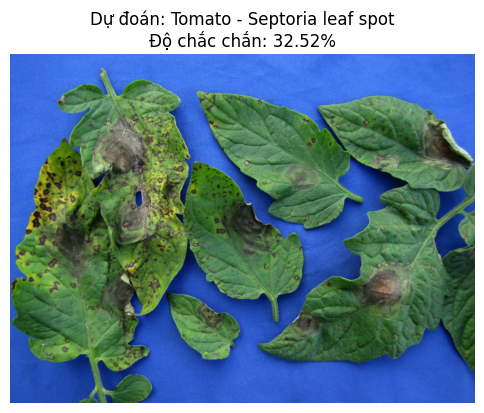

In [16]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import os
import time
import matplotlib.pyplot as plt # <--- THÊM THƯ VIỆN NÀY

# ==============================================================================
# BƯỚC 1: SAO CHÉP Y HỆT ĐỊNH NGHĨA MODEL TỪ FILE TRAINING
# ==============================================================================
print("🏗️  Defining model architecture...")

class SimpleMobileNetV3(nn.Module):
    def __init__(self, num_classes):
        super(SimpleMobileNetV3, self).__init__()
        self.mobilenet = models.mobilenet_v3_large() 
        in_features = self.mobilenet.classifier[3].in_features
        self.mobilenet.classifier[3] = nn.Linear(in_features, num_classes)
    
    def forward(self, x):
        return self.mobilenet(x)

print("✅ Model architecture defined successfully.")

# ==============================================================================
# BƯỚC 2: HÀM DỰ ĐOÁN (ĐÃ NÂNG CẤP ĐỂ HIỂN THỊ ẢNH)
# ==============================================================================
def predict_single_image(model, image_path, class_names, device):
    """
    Dự đoán trên một file ảnh, in kết quả và hiển thị ảnh.
    """
    if not os.path.exists(image_path):
        print(f"❌ Lỗi: Không tìm thấy ảnh tại đường dẫn '{image_path}'")
        return

    print(f"\n🔮 PREDICTING IMAGE 🔮")
    print(f"📁 File: {os.path.basename(image_path)}")
    
    try:
        # Tải ảnh gốc để hiển thị
        original_image = Image.open(image_path).convert('RGB')
        
        # Tiền xử lý ảnh để đưa vào model
        transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        tensor = transform(original_image).unsqueeze(0).to(device)
        
        model.eval()
        
        with torch.no_grad():
            outputs = model(tensor)
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            confidence, predicted_idx_tensor = torch.max(probabilities, 1)
            
            pred_idx = predicted_idx_tensor.item()
            confidence_score = confidence.item() * 100
            pred_class = class_names[pred_idx].replace('___', ' - ').replace('_', ' ')

        # --- PHẦN HIỂN THỊ ẢNH ---
        plt.figure(figsize=(6, 7))
        plt.imshow(original_image)
        
        # Tạo tiêu đề cho ảnh
        title = f"Dự đoán: {pred_class}\n" \
                f"Độ chắc chắn: {confidence_score:.2f}%"
        
        plt.title(title, fontsize=12)
        plt.axis('off') # Ẩn các trục tọa độ
        plt.show() # Hiển thị cửa sổ ảnh
        # --------------------------
        
    except Exception as e:
        print(f"   ❌ Đã xảy ra lỗi trong quá trình dự đoán: {e}")

# ==============================================================================
# BƯỚC 3: KỊCH BẢN CHÍNH - TẢI CHECKPOINT VÀ GỌI HÀM DỰ ĐOÁN
# ==============================================================================
if __name__ == '__main__':
    # --- ⚙️ CẤU HÌNH ---
    FINETUNE_PATH = "./modelsCP/mobilenet_finetune/mobilenet_finetune_best.pth"
    IMAGE_TO_PREDICT = "./realImage/late_blight_tomato_unusual-symptomsx1200.jpg" # ✏️ THAY ĐỔI ẢNH CỦA BẠN Ở ĐÂY
    # -----------------
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🖥️  Using device: {device}")
    
    model = None
    class_names = []
    
    print("\n🔄 LOADING FINETUNE MODEL...")
    print("=" * 50)
    
    if os.path.exists(FINETUNE_PATH):
        try:
            print(f"   📂 Reading checkpoint from: {FINETUNE_PATH}")
            checkpoint = torch.load(FINETUNE_PATH, map_location=device)
            
            num_classes = checkpoint['num_classes']
            print(f"   📊 Found {num_classes} classes in checkpoint.")

            print("   🏗️  Rebuilding model with 'SimpleMobileNetV3' wrapper...")
            model = SimpleMobileNetV3(num_classes=num_classes).to(device)

            print("   ⚡ Loading weights into model...")
            model.load_state_dict(checkpoint['model_state_dict'])
            
            class_names = checkpoint['class_names']
            accuracy = checkpoint.get('accuracy', 0.0)
            
            print("\n✅ MODEL LOADED SUCCESSFULLY!")
            print(f"   🎯 Model Accuracy: {accuracy:.2f}%")
            print("=" * 50)

        except Exception as e:
            print(f"   ❌ FAILED to load checkpoint: {e}")
            model = None
    else:
        print(f"   ❌ Checkpoint file not found at: {FINETUNE_PATH}")

    if model:
        predict_single_image(model, IMAGE_TO_PREDICT, class_names, device)